In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input"))

from PIL import Image
import matplotlib.pyplot as plt

import tensorflow as tf

%matplotlib inline

# Any results you write to the current directory are saved as output.


['sample_submission.csv', 'description.md', 'test.zip', 'train.csv', 'sample_submission.csv.zip', 'test', 'train.zip', 'aerial-cactus-identification', 'train', 'train.csv.zip']


2026-01-07 06:07:25.312390: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767766045.325666      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767766045.329822      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-07 06:07:25.347222: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
os.listdir('../input/')


['sample_submission.csv',
 'description.md',
 'test.zip',
 'train.csv',
 'sample_submission.csv.zip',
 'test',
 'train.zip',
 'aerial-cactus-identification',
 'train',
 'train.csv.zip']

In [3]:
df = pd.read_csv('../input/train.csv')
df.head(10)


,id,has_cactus
0,2de8f189f1dce439766637e75df0ee27.jpg,1
1,36704d250f236238e7f996812c48235d.jpg,1
2,eacde22fdc8c175972a5768e3daa8bc9.jpg,1
3,5d442f834da5e57d22b24802c32a8ca8.jpg,1
4,152491e0daf75c0e669400300ff7e645.jpg,1
5,7aea2cdb1333f960d3ffd0eb4889ad7f.jpg,1
6,c096417915f70c41b2a2ff732bf63e6b.jpg,1
7,924345ef46d9772e9a8adb4920c1e65c.jpg,1
8,f919c1bc54e15203575d90a2b2e72a04.jpg,1
9,832654dea6e6d520715cd80911a50e1c.jpg,1


In [4]:
os.listdir('../input/test/test')


['76bad42ebc1ed65f7f50c06fd17849db.jpg',
 'f620bd2745d51c25cd05eca4f7c4da94.jpg',
 '0e47e71ea2829d6d88944482ada145a5.jpg',
 'd66598ea219072e9c0b98e1a162cc8f6.jpg',
 '3288a35f07e97293155203bec36c0a8d.jpg',
 '05e406596f183ddc1d771de2c7af6eb1.jpg',
 '454f59bef7140259bbb9875a836355cd.jpg',
 '589de864efdaa264d19112d946d17826.jpg',
 'b5f7b64eb412f94d352ad01e6e6106d7.jpg',
 '890ae48097378d600cfbc0b93566c155.jpg',
 '9d052bee693b53a48fa3503f1eafbea8.jpg',
 '2c7e6f5d7b6165001bbb9523d2efd4ee.jpg',
 '106b2f33541f5b23cb4805cdffc87db6.jpg',
 '712ed765f98a19b8cd21a5a8c96ff4a5.jpg',
 'cebe5aeeb39cdc7349e4783353e6254f.jpg',
 'df1e111ef8ec047a456ba11ba7ef96f0.jpg',
 '73ca87e899048fb0f1a020361af74eac.jpg',
 '4e98c9d667be711ac1b593e79906d2e7.jpg',
 'f852db0e5fcded7e80be3a8b3993a66d.jpg',
 '8886a5647fee68f9ef200fa2bd7b9c22.jpg',
 '74f611a1f3d41313fe35ec75c50e3c15.jpg',
 '2246209a6d93a68be1dbf1fcd66e78ab.jpg',
 'a543d2de2b076d4ddc5406583221ea8d.jpg',
 'cc1a534bf86d2adbb449091229fa2148.jpg',
 '67d8fe28186d32

In [5]:
os.listdir('../input/train/train')


['775da0be6da934cb05d6bc7955931dd9.jpg',
 '65a52562f1ebce1166d9737ac9d1c0e5.jpg',
 'd6243c9afe26f34c5dd8a27bb76210ce.jpg',
 'e405a1ed71aec5a0119dfe616252cf35.jpg',
 '6a5cd7c3d4e5b917fb37e06270aa1d2e.jpg',
 '3c521b66a89ef29344f29889c0ccf6e3.jpg',
 '5cfdc3a02cbf7c68b5eaf9a606467a8f.jpg',
 '54dd34eeb1d2d7d0c304ff229e0781ff.jpg',
 '4c2d70858685be7d59970e7b87049a59.jpg',
 '2b35aa2cc4472e298c264e89b96fa17b.jpg',
 '54a409762783a325db8e87f70d2604d1.jpg',
 'cf4ef20c47177642173f81fdf5f05a2c.jpg',
 '85a6b16215ef5ad3e6865e2e80c6ff60.jpg',
 '2f9ebd2d0756753d03565f185ee5a7fb.jpg',
 '9e5de204cb1cda26f367b217040ad1b8.jpg',
 'ddb34bc19d8705b97ef4b7b9d72522bf.jpg',
 '9d49a887c2429ff7c7513652db115e63.jpg',
 'c205045432de9e618666dfa12ab674fe.jpg',
 '5db31431afa4fe69e537127ca91f61fb.jpg',
 'e023f78930aedd4c79495dbd968be42d.jpg',
 '9530c4e539b4ab0522e5a3c194367909.jpg',
 '98a37ee1d1c363a4016d48f05fc64731.jpg',
 'b8fa8a47274bebf9a9a78c59f5676825.jpg',
 'b28c6c0c49c754bfb33a46f0aaf52e12.jpg',
 'b0ddd6e7bd9c92

In [6]:
data_dir = '../input/train/train/'
filename = df['id'][0]
path = os.path.join(data_dir, filename)
path

test_dir = '../input/test/test/'


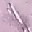

In [7]:
image_pil = Image.open(path)
image_pil


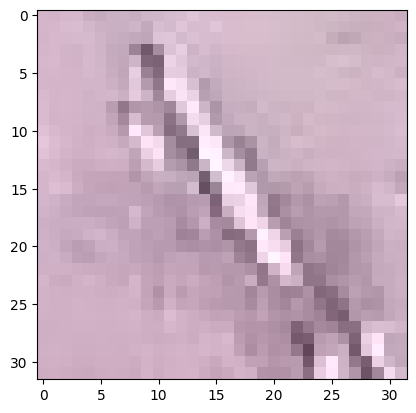

In [8]:
image = np.array(image_pil)
plt.imshow(image)
plt.show()


In [9]:
has_cactus = df['has_cactus'][0]
has_cactus


1

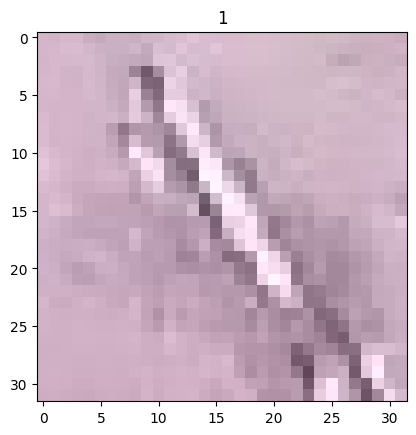

In [10]:
image = np.array(image_pil)
plt.title(has_cactus)
plt.imshow(image)
plt.show()


In [11]:
np.mean(df['has_cactus']) # cactus가 포함될 비율


0.7497707231040565

In [12]:
np.sum(df['has_cactus']), len(df['has_cactus'])


(10628, 14175)

In [13]:
image.shape


(32, 32, 3)

In [14]:
np.min(image), np.max(image)


(69, 255)

In [15]:
#def get_label(path):
#    if df['id'] == path.split('/')[-1]
    

def get_data(pathtuple):
    path, label = pathtuple
    image_pil = Image.open(path)
    image = np.array(image_pil)
    image = image/255.0
    label=tf.keras.utils.to_categorical(label,2)

    #return image, label
    return image.astype(np.float32), label.astype(np.float32)

    
    


In [16]:
tf.keras.utils.to_categorical?


In [17]:
heights = []
widths = []
train_arr = []
test_arr = []

train_filenames = []
index = 0

for filename in df['id']:
    path = os.path.join(data_dir, filename)
    train_filenames.append((path, df['has_cactus'][index]))
    index = index + 1
    
#trainimage, trainlabel=get_data(train_filenames[0])
#plt.imshow(trainimage)
#print(trainlabel)
    
for testfilename in os.listdir(test_dir):
    #print(testfilename)
    path = os.path.join(test_dir, testfilename)
    image_pil = Image.open(path)
    image = np.array(image_pil)
    image = image/255.0
    test_arr.append(image.astype(np.float32))
    
test_data = np.array(test_arr)


IsADirectoryError: [Errno 21] Is a directory: '../input/test/test/test'

In [18]:
# batch dataset

#batch_paths = train_filenames[:8]

def make_batch(batch_paths):

    batch_images = []
    batch_labels = []

    for pathtuple in batch_paths:
        path, label = pathtuple
        image, label = get_data(pathtuple)
        batch_images.append(image)
        batch_labels.append(label)

    batch_images = np.array(batch_images)
    batch_labels = np.array(batch_labels)

    return batch_images, batch_labels

#images, labels = make_batch(batch_paths)
#images.shape, labels.shape 


In [19]:
batch_size = 32


In [20]:
def data_gen(data_paths, is_training=True):
    global_step = 0
    steps_per_epoch = len(data_paths) // batch_size
    while True:
        step = global_step % steps_per_epoch
        if step == 0:
            np.random.shuffle(data_paths)
        images, labels = make_batch(data_paths[step*batch_size:(step+1)*batch_size])
        global_step += 1
        yield images, labels


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

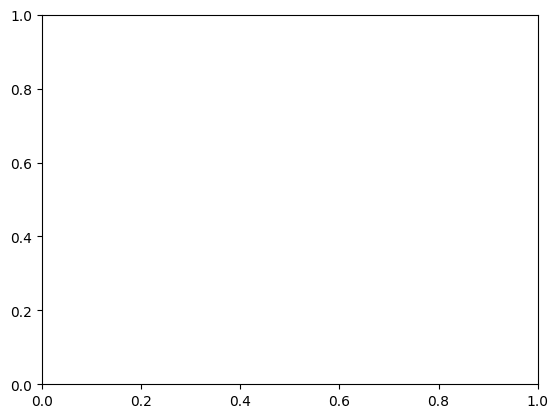

In [21]:
#generator = data_gen(train_paths)
generator = data_gen(train_filenames)

for i, (img, lbl) in enumerate(generator):
    if i < 5:
        plt.title(i + lbl[0])
        plt.imshow(img[0])
        plt.show()
        #print(lbl)
    else:
        break
        


In [22]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function
from __future__ import unicode_literals

import os
import time

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import clear_output

import tensorflow as tf
from tensorflow.keras import layers
tf.enable_eager_execution()

os.environ["CUDA_VISIBLE_DEVICES"]="0"


AttributeError: module 'tensorflow' has no attribute 'enable_eager_execution'

In [23]:
batch_size = 32
num_epochs = 20
learning_rate = 0.001

num_classes = 2
input_shape = (32, 32, 3)


In [24]:
# VGG16
inputs = layers.Input(input_shape)
net = layers.Conv2D(64, (3, 3), padding='same')(inputs)
net = layers.Conv2D(64, (3, 3), padding='same')(net)
net = layers.Conv2D(64, (3, 3), padding='same')(net)
net = layers.BatchNormalization()(net)
net = layers.Activation('relu')(net)
net = layers.MaxPooling2D(pool_size=(2, 2))(net)

net = layers.Conv2D(128, (3, 3), padding='same')(net)
net = layers.Conv2D(128, (3, 3), padding='same')(net)
net = layers.Conv2D(128, (3, 3), padding='same')(net)
net = layers.BatchNormalization()(net)
net = layers.Activation('relu')(net)
net = layers.MaxPooling2D(pool_size=(2, 2))(net)
net = layers.Dropout(0.25)(net)

net = layers.Conv2D(256, (3, 3), padding='same')(net)
net = layers.Conv2D(256, (3, 3), padding='same')(net)
net = layers.Conv2D(256, (3, 3), padding='same')(net)
net = layers.BatchNormalization()(net)
net = layers.Activation('relu')(net)
net = layers.MaxPooling2D(pool_size=(2, 2))(net)
net = layers.Dropout(0.25)(net)

net = layers.Conv2D(512, (3, 3), padding='same')(net)
net = layers.Conv2D(512, (3, 3), padding='same')(net)
net = layers.Conv2D(512, (3, 3), padding='same')(net)
net = layers.BatchNormalization()(net)
net = layers.Activation('relu')(net)
net = layers.MaxPooling2D(pool_size=(2, 2))(net)
net = layers.Dropout(0.25)(net)

net = layers.Conv2D(512, (3, 3), padding='same')(net)
net = layers.Conv2D(512, (3, 3), padding='same')(net)
net = layers.Conv2D(512, (3, 3), padding='same')(net)
net = layers.BatchNormalization()(net)
net = layers.Activation('relu')(net)
net = layers.MaxPooling2D(pool_size=(2, 2))(net)
net = layers.Dropout(0.25)(net)

# net = layers.GlobalAveragePooling2D()(net)
net = layers.Flatten()(net)
net = layers.Dense(512)(net)
net = layers.Activation('relu')(net)
net = layers.Dropout(0.5)(net)
net = layers.Dense(num_classes)(net)
net = layers.Activation('softmax')(net)

model = tf.keras.Model(inputs=inputs, outputs=net)


2026-01-07 06:07:33.700140: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1767766053.700810      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:45:00.0, compute capability: 8.6


In [25]:
model.compile(loss='categorical_crossentropy', 
             optimizer=tf.keras.optimizers.Adam(learning_rate),
             metrics=['accuracy'])


In [26]:
#callbacks = [
#    tf.keras.callbacks.TensorBoard(log_dir=os.path.join(os.getcwd(),'logs'))
#]


In [27]:
model.fit_generator?


Object `model.fit_generator` not found.


In [28]:
steps_per_epoch = len(train_filenames) // batch_size

history=model.fit_generator(generator=data_gen(train_filenames),
                    steps_per_epoch=steps_per_epoch,
                    epochs=num_epochs,
                    verbose=1)
                    #callbacks=callbacks)


AttributeError: 'Functional' object has no attribute 'fit_generator'

In [29]:
print(history.history.keys())


NameError: name 'history' is not defined

In [30]:
# summarize history for accuracy
plt.plot(history.history['acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()


NameError: name 'history' is not defined

In [31]:
test_predictions = []

for i in range(test_data.shape[0]):
#for i in range(1):
    predictions = model.predict(np.expand_dims(test_data[i],0))
    test_predictions.append(np.argmax(tf.squeeze(predictions)))


NameError: name 'test_data' is not defined

In [32]:
#print(test_predictions[0])
#len(test_predictions)


In [33]:
test_filenames=os.listdir(test_dir)

test_df = pd.DataFrame({'id': test_filenames, 'has_cactus': test_predictions },columns=['id','has_cactus'])

test_df.to_csv('test_submission.csv', index=False)


ValueError: All arrays must be of the same length

In [34]:
#test_batches_per_epoch = len(test_paths) // batch_size
#model.evaluate_generator(data_gen(test_paths, False),
#                        steps = test_batches_per_epoch,
#                        verbose=1)


In [35]:
#model.predict(np.expand_dims(image,0))


In [36]:
#model.save(model.name+'_cactus.h5')

#load model
#model = tf.keras.models.load_model(model.name + '_cactus.h5')


In [37]:
#!tensorboard --logdir=./logs


In [38]:
#t = [('a',1),('b',2),('c',3)]
#np.random.shuffle(t)
#print(t)


In [39]:
#(df['id']==path.split('/')[-1])==1


In [40]:
#from tqdm import tqdm_notebook
